# DQCode Tutorial
DQCode can be used to find optimised encoding circuits for logical $|0\rangle_L$ states of Quantum Error Correction codes on distributed Type-II architectures. The $\texttt{scripts/}$ folder exposes the main components of the search and evaluation pipeline. In this tutorial, we patch these scripts together to demonstrate the pipeline for a trivariate bicycle QEC code, the [[12,2,3]] code, on a 3-core architecture, where each QPU hosts 4 qubits.

__DISCLAIMER__: The purpose of this notebook is to contextualise the DQCode scripts. However, it is not devised as a stand-alone executable. We thus ask the user to view this notebook as a guideline of how to use the scripts privided in the $\texttt{scripts/}$ folder, rather than executing execution cells in this notebook. To this end, we outline the pipeline, indicating which commands to run in a Julia REPL. The general instructions for this are given in the README file. Having executed these instructions, one can then proceed with the visualisation tools in this notebook, which draw upon the data and results stored by the REPL runs. This ensures that saved datatypes are not compromised, and allows for better terminal output experience. As such, this notebook simply provides a framework for navigating DQCode; the instructions for running examples in a Julia REPL are provided in the README file, and for each cell command in this notebook, we provide the corresponding REPL command in a commented-out format. In other words, while this notebook provides an overview over DQCode, running this notebook as a monolithic file is not recommended.

Throughout this tutorial, we assume that the user runs the respective indicated scripts, adapting the scripts per the code in questions. For this notebook, we set the experiment label in $\texttt{/scripts/dqc\_setup.jl}$ (and all other scripts) to $\texttt{steane\_4\_3}$.

In [1]:
DQCode_dir = joinpath(@__DIR__, "..")
using Pkg
Pkg.activate(DQCode_dir)
include(joinpath(DQCode_dir, "src/DQCode.jl"))

  Activating project at `~/Tim/projects/DQCode`


Main.DQCode

In [2]:
using Serialization, Images, FileIO, CSV, DataFrames

## Setting up CSS code and Type-II architecture


In [3]:
# include("$DQCode_dir/scripts/execution/dqc_setup.jl")

# ------------- In Your Julia REPL  -----------------
#       include("scripts/execution/dqc_setup.jl")

We can check tht the code parameters and network architecture have been correctly initialised.

In [13]:
steane_dir = joinpath(DQCode_dir, "data/Steane/[4, 3]")

network_specs = deserialize( joinpath(steane_dir, "network_specs.jls"))
code_params = deserialize( joinpath(steane_dir, "code_params.jls"))

network_specs, code_params

(Main.DQCode.Types.NetworkSpecifications([4, 3], 2, [2, 3, 6, 7, 1, 4, 5], [(1, 5), (2, 5), (3, 5), (4, 6), (5, 7), (6, 7)], [5, 1, 2, 6, 7, 3, 4], [1, 1, 1, 1, 2, 2, 2], [1, 2, 3, 4, 5, 6, 7], [8, 9], 7, 2, 1, 9), Main.DQCode.Types.CodeParameters(QECCore.Steane7(), 3, Stabilizer 1×7, Stabilizer 7×7, [0 0 … 2 0; 0 0 … 1 0; … ; 2 0 … 2 0; 1 0 … 1 0], 7, 1, 3))

The code setup script has determined a mapping of qubits favorable to distributed stabiliser measurment. Let's inspect the mapping

In [14]:
for (idx, core_size) in enumerate(network_specs.register_sizes)
    @info "Core $idx contains qubits $(network_specs.mapping[ (idx>1 ? sum(network_specs.register_sizes[1:idx-1]) +1 : 1 )    : (idx>1 ? sum(network_specs.register_sizes[1:idx-1]) +1 : 1 )  + core_size-1]  )"
end

┌ Info: Core 1 contains qubits [2, 3, 6, 7]
└ @ Main /Users/tim/Tim/projects/DQCode/examples/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y112sZmlsZQ==.jl:2
┌ Info: Core 2 contains qubits [1, 4, 5]
└ @ Main /Users/tim/Tim/projects/DQCode/examples/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y112sZmlsZQ==.jl:2


## Qiskit Baseline Encoding

In [8]:
#include("$DQCode_dir/scripts/execution/dqc_qiskit_baseline.jl")

# ------------- for Julia REPL (recommended) -----------------
#    include("scripts/execution/dqc_qiskit_baseline.jl")


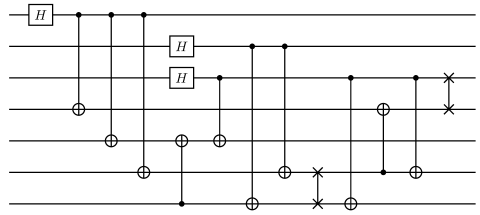

In [15]:
load(joinpath(steane_dir, "qiskit_encoding/qiskit_encoding_circuit.png"))

## Genetic Search for efficient encoding circuits

We now initialise our genetic algorithm, which is seeded with optimised Gottesman encoding circuits as warm-start circuit. 

For better logging experience, we recommend running the genetic search via the Julia REPL, as discussed in the README file (the corresponding REPL command is commented out below).

In [ ]:
#include("$DQCode_dir/scripts/execution/dqc_gott_ga.jl") 

# ------------- for Julia REPL (recommended) -----------------
#        include("scripts/execution/dqc_gott_ga.jl")

This script has saved all relevant data from the genetic search to the $\texttt{data/}$ folder. We first inspect the Gottesman encoding circuit as well as the DQC version of it.

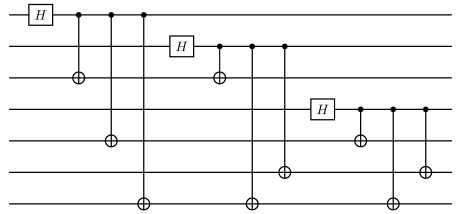

In [16]:
load(joinpath(steane_dir, "warmstart_ga/gott_encoding_circuit.png"))

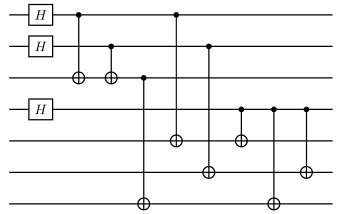

In [17]:
load(joinpath(steane_dir, "warmstart_ga/gott_circuit_dqc_compiled.png"))

Finally, let's take a look at the optimised circuit the genetic search produced:

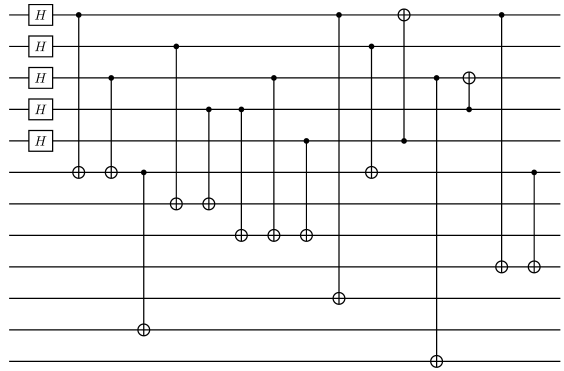

In [18]:
load(joinpath(trivariate_dir, "warmstart_ga/GA_circuit.png"))

How did the optimisation perform in a DQC setting?

In [19]:
df = CSV.read(joinpath(steane_dir, "warmstart_ga/warm_start_ga_stats.csv"), DataFrame)

Row,method,verfied,gate_counts
,String15,Bool,String15
1,Gottesman,true,"[3, 5, 4]"
2,dqc_compiled,true,"[3, 5, 3]"
3,GA,true,"[3, 6, 2]"


Let's compare with the qubit mapping we identified earlier. Since qubits 2,3,6 and 7 are in the first core, in the above circuit we indeed find two telegates (the remaining CNOT gates are intra-core): The first CNOT(1,3) spans both cores, and the CNOT(4,7) does as well.

## DQC Simulation

Using the optimised GA circuit, we now run the DQC simulation. In $\texttt{scripts/dqc\_sim}$, we can set the corresponding noise range. For the below results, we swept noise $p \in [5e-5,1e-3]$, with $p_{Bell} \in [1e-3, 5e-2]$, with ... values each. Recall that we have set the telegate idle depth to $10$, the single-qubit error rate to $p/100$ and the idling rate to $p/10$.

Again, for better logging experience, it is recommended to run the below command in a Julia REPL, following the instructions in the README file (REPL command commented out for convenience).

In [20]:
#include("$DQCode_dir/scripts/execution/dqc_sim.jl")

# ------------- for Julia REPL (recommended) -----------------
#        include("scripts/execution/dqc_sim.jl")

Let us inspect the verification circuit that was appended to our optimised circuit in order to make it fault-tolerant.

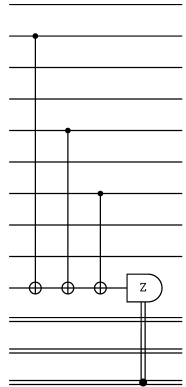

In [21]:
load(joinpath(steane_dir, "simulation_FT/verification_circuit.png"))

Next, let us take a look at the DQC executable circuit, including the circuit-level noise and Bell pair initialisation noise we wish to examine.

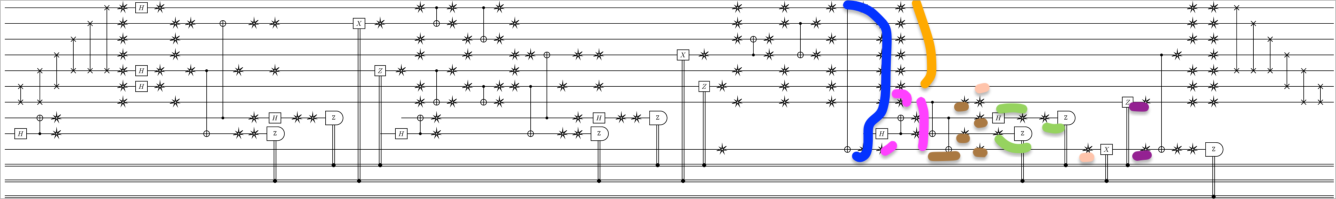

In [22]:
load(joinpath(steane_dir, "simulation_FT/DQC_circuit.png"))

There's a lot going on in this circuit. Firstly, the first seven qubits are our data qubits. The (noiseless) SWAP operations at the very beginning of the circuit serve to visualise that we have mapped our qubits in a specific way (based on the hypergraph partitioning determined by distributed QEC cycles). (The SWAP operations are noiseless, since in a real experiment, one would simply relabel the qubits at the beginning of the circuit; this is different from SWAP operations that occur in the middle of the circuit, which might necessitate tele-operations). Additionally, we find two communication qubits (qubits $8$ and $9$), which enable our telegates between the two cores. Earlier, we identified that two CNOT gates are telegates: CNOT(1,3) and CNOT(4,7). These telegates have been replaced with the corresponding the EJPP protocol, making use of the respective communication qubits. The $10^{\text{th}}$ qubit stems from the verification circuit, and is used to discard runs that violated the FT criterion (and resulted in harmful errors from low-weight errors). Also, there are classical lines storing the measurement information from the circuit.
The 

The full circuit, including noise-free stabiliser measurements, can also be visualised.

ADD ANALYIS OF HOW MANY ANCILLAS

In [68]:
#load(joinpath(steane_dir, "simulation_FT/full_circuit.txt"))

ArgumentError: ArgumentError: No file exists at given path: /Users/tim/Tim/projects/DQCode/examples/../data/Steane/[4, 3]/simulation_FT/full_circuit.txt

We can inspect the data stored by the above simulation.

In [23]:
df = CSV.read(joinpath(steane_dir, "simulation_FT/dqc_sim_data.csv"), DataFrame)

Row,p,p_bell,logical_error_rate,acceptance_ratio,discarded_runs,n_samples,logical_failures,avg_fidelity,z_error_pre_decoding_rate,x_error_pre_decoding_rate,depth_cx_layers,depth_telegate_layers,encoding_circ_gate_counts,total_single_qubit_count,total_two_qubit_count,total_telegate_count,num_meas
,Float64,Float64,Float64,Float64,Int64,Int64,String7,Float64,Float64,Float64,Int64,Int64,String15,Int64,Int64,Int64,Int64
1,5.0e-5,0.001,0.0,0.99776,112,50000,[0.0],1.0,0.00158355,0.000481078,8,3,"[3, 6, 2]",3,8,3,1
2,0.000105737,0.001,0.0,0.99634,183,50000,[0.0],1.0,0.00260955,0.000943453,8,3,"[3, 6, 2]",3,8,3,1
3,0.000223607,0.001,4.02544e-5,0.99368,316,50000,[2.0],0.99996,0.00470977,0.00239514,8,3,"[3, 6, 2]",3,8,3,1
4,0.000472871,0.001,6.07177e-5,0.98818,591,50000,[3.0],0.999939,0.0100791,0.0047967,8,3,"[3, 6, 2]",3,8,3,1
5,0.001,0.001,0.000163656,0.97766,1117,50000,[8.0],0.999836,0.019966,0.00943068,8,3,"[3, 6, 2]",3,8,3,1
6,5.0e-5,0.00265915,0.0,0.9947,265,50000,[0.0],1.0,0.00309641,0.000522771,8,3,"[3, 6, 2]",3,8,3,1
7,0.000105737,0.00265915,2.0128e-5,0.99364,318,50000,[1.0],0.99998,0.00364317,0.000905761,8,3,"[3, 6, 2]",3,8,3,1
8,0.000223607,0.00265915,0.0,0.9907,465,50000,[0.0],1.0,0.00633895,0.00220046,8,3,"[3, 6, 2]",3,8,3,1
9,0.000472871,0.00265915,2.02881e-5,0.9858,710,50000,[1.0],0.99998,0.0124975,0.00458511,8,3,"[3, 6, 2]",3,8,3,1


With the logical_rate analysis script, we can now visualise this data in a meaningful way.

In [71]:
include("$DQCode_dir/scripts/analysis/logical_rate.jl")

# ------------- for Julia REPL (recommended) -----------------
#     include("scripts/analysis/logical_rate.jl")

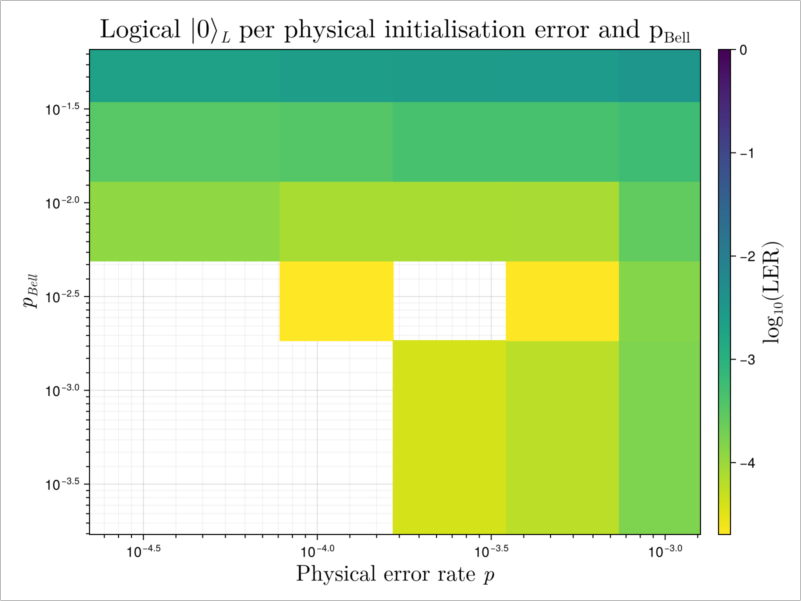

In [72]:
load(joinpath(steane_dir, "simulation_FT/2d_heatmap.png"))

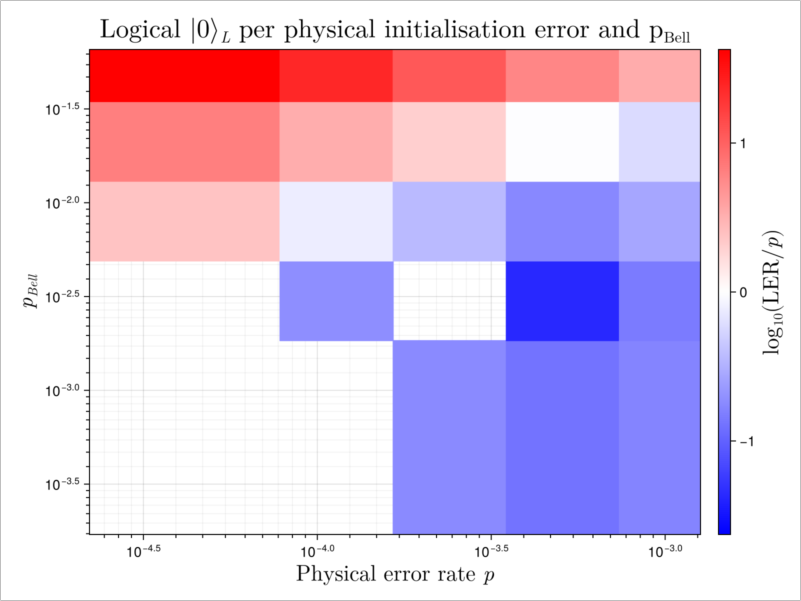

In [73]:
load(joinpath(steane_dir, "simulation_FT/2d_heatmap_ratio.png"))


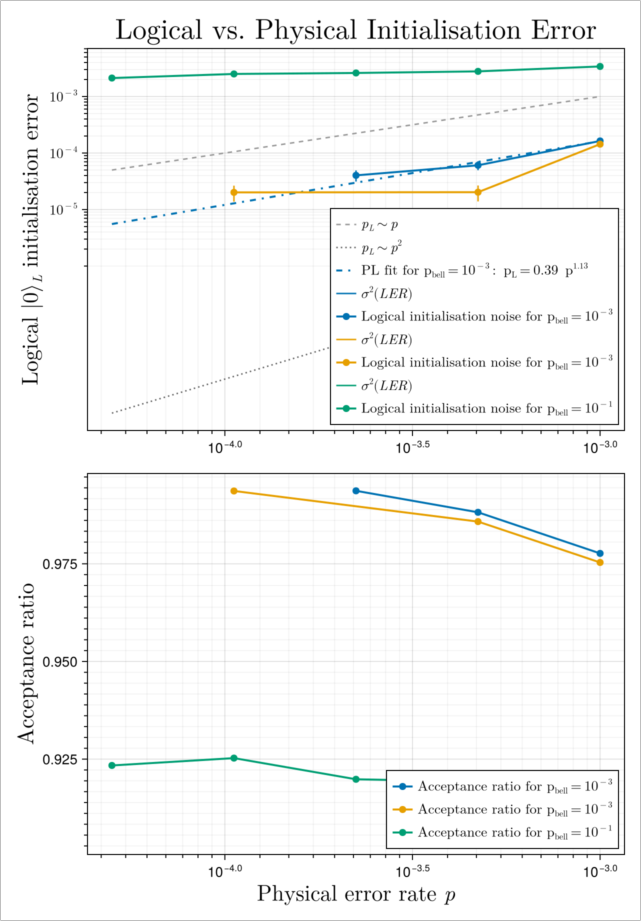

In [74]:
load(joinpath(steane_dir, "simulation_FT/qec_threshold.png"))

ADD ANALSYSIS OF PRE-DECODING ERROR